<a href="https://colab.research.google.com/github/RebecaTavaress/knn_iris_classifier/blob/main/knn_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# IMPORTAÇÃO DAS BIBLIOTECAS

# Implementação do algoritmo KNN
from sklearn.neighbors import KNeighborsClassifier

# Carrega o dataset Iris pronto do sklearn
from sklearn.datasets import load_iris

# Divide os dados em treino e teste
from sklearn.model_selection import train_test_split

# Faz busca automática do melhor parâmetro (melhor K)
from sklearn.model_selection import GridSearchCV

# Calcula a porcentagem de acertos do modelo
from sklearn.metrics import accuracy_score

# Calcula a precisão do modelo
from sklearn.metrics import precision_score

# Calcula o recall (sensibilidade)
from sklearn.metrics import recall_score

# Calcula o F1-score
from sklearn.metrics import f1_score

# Gera relatório completo com métricas
from sklearn.metrics import classification_report

# Cria matriz de confusão
from sklearn.metrics import confusion_matrix

# Biblioteca para criação de gráficos
import matplotlib.pyplot as plt

# Biblioteca para gráficos mais bonitos e heatmaps
import seaborn as sns

# Biblioteca para cálculos matemáticos e vetores
import numpy as np

# Biblioteca para manipulação de tabelas/dados
import pandas as pd

In [3]:
# carregar dataset
iris = load_iris()

# características
X = iris.data

# classes
y = iris.target

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (150, 4)
Formato de y: (150,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3, #Define a porcentagem dos dados que vão para teste
    random_state=42 #Esse número controla a aleatoriedade da divisão
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (105, 4)
Teste: (45, 4)


In [5]:
#criar modelo knn (criando classificador)
knn = KNeighborsClassifier(n_neighbors=3)

In [6]:
#treinar modelo
knn.fit(X_train, y_train)

print("Modelo treinado!")

Modelo treinado!


In [7]:
#fazer previsões
y_pred = knn.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


In [8]:
#mostrar metricas
acuracia = accuracy_score(y_test, y_pred)

precisao = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("RESULTADOS DO MODELO")
print("-" * 30)

print("Acurácia:", acuracia)
print("Precisão:", precisao)
print("Recall:", recall)
print("F1-score:", f1)

RESULTADOS DO MODELO
------------------------------
Acurácia: 1.0
Precisão: 1.0
Recall: 1.0
F1-score: 1.0


In [10]:
#relatorio completo
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
        )
    )

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



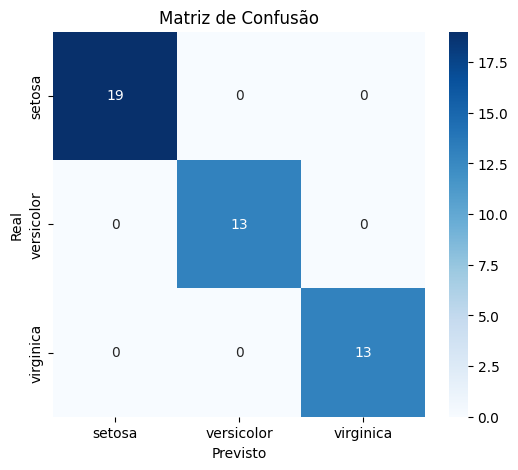

In [12]:
#matriz de confusão
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

In [18]:
#testar K de 1 até 10

valores_k = range(1, 11)

acuracias = []

for k in valores_k:

    modelo = KNeighborsClassifier(
        n_neighbors=k
    )

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, pred)

    acuracias.append(acc)

    print(f"K={k} -> Acurácia={acc:.4f}")

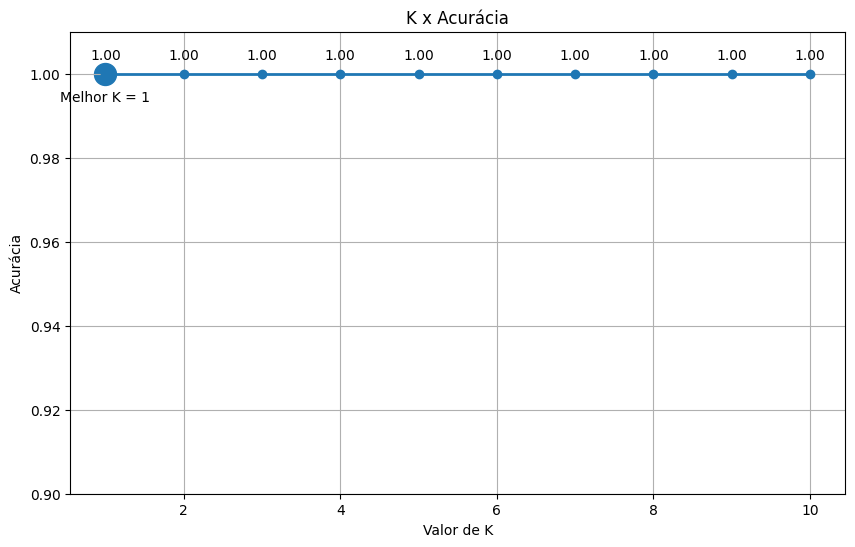

In [25]:
# MELHOR K

melhor_k = valores_k[np.argmax(acuracias)]

melhor_acuracia = max(acuracias)

# GRÁFICO

plt.figure(figsize=(10,6))

plt.plot(
    valores_k,
    acuracias,
    marker='o',
    linewidth=2
)

# MOSTRAR TODOS OS VALORES
for i in range(len(valores_k)):

    plt.annotate(
        f'{acuracias[i]:.2f}',
        (valores_k[i], acuracias[i]),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

# DESTACAR MELHOR K
plt.scatter(
    melhor_k,
    melhor_acuracia,
    s=250
)

plt.annotate(
    f'Melhor K = {melhor_k}',
    (melhor_k, melhor_acuracia),
    textcoords="offset points",
    xytext=(0,-20),
    ha='center'
)

plt.title("K x Acurácia")

plt.xlabel("Valor de K")

plt.ylabel("Acurácia")

plt.ylim(0.90, 1.01)

plt.grid(True)

plt.show()

In [21]:
#grid search
parametros = {
    'n_neighbors': range(1, 11)
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    parametros,
    cv=30
)

grid.fit(X, y)

print("Melhor K:", grid.best_params_)
print("Melhor Acurácia:", grid.best_score_)

Melhor K: {'n_neighbors': 3}
Melhor Acurácia: 0.9666666666666667


In [ ]:
#30 realizações
melhor_k = grid.best_params_['n_neighbors']

resultados = []

for i in range(30):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3
    )

    modelo = KNeighborsClassifier(
        n_neighbors=melhor_k
    )

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, pred)

    resultados.append(acc)

print(resultados)

[0.9555555555555556, 0.9555555555555556, 0.9777777777777777, 0.9777777777777777, 0.9333333333333333, 0.9555555555555556, 0.9555555555555556, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 1.0, 0.9555555555555556, 0.9555555555555556, 0.9111111111111111, 1.0, 0.9333333333333333, 0.9333333333333333, 0.9555555555555556, 0.9777777777777777, 0.9555555555555556, 1.0, 0.9111111111111111, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 1.0, 1.0, 0.9333333333333333, 0.9777777777777777, 0.9333333333333333]


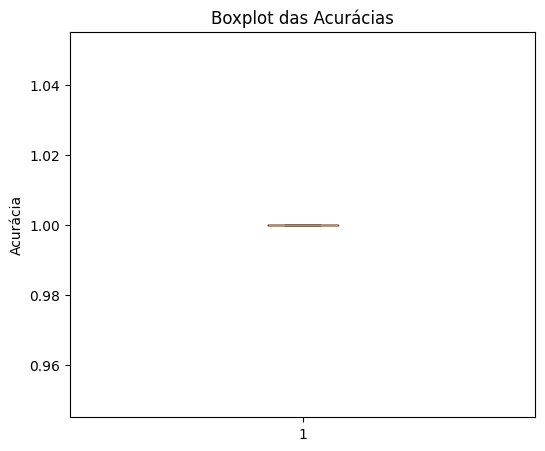

In [22]:
#boxplot
plt.figure(figsize=(6,5))

plt.boxplot(acuracias)

plt.title("Boxplot das Acurácias")

plt.ylabel("Acurácia")

plt.show()

In [26]:
#média final
media = np.mean(acuracias)
desvio = np.std(acuracias)

print("Média:", media)
print("Desvio padrão:", desvio)

Média: 1.0
Desvio padrão: 0.0
